In [2]:
import numpy as np
arr = np.array([2,3,4,6,7,8,9,12,13,16,17,23,25,27,34,37,201])
arr

array([  2,   3,   4,   6,   7,   8,   9,  12,  13,  16,  17,  23,  25,
        27,  34,  37, 201])

In [3]:
Q1= np.percentile(arr,25)
Q3= np.percentile(arr,75)

In [4]:
IQR= Q3-Q1
IQR

np.float64(18.0)

In [5]:
UF = Q3 + (1.5*IQR)
UF

np.float64(52.0)

In [6]:
LF = Q1 - (1.5*IQR)
LF

np.float64(-20.0)

In [7]:
l =[]
for i in arr:
  if i <= UF and i>= LF:
    l.append(i)
arr2 =np.array(l)

In [8]:
print(arr)
print(arr2)

[  2   3   4   6   7   8   9  12  13  16  17  23  25  27  34  37 201]
[ 2  3  4  6  7  8  9 12 13 16 17 23 25 27 34 37]


<Axes: >

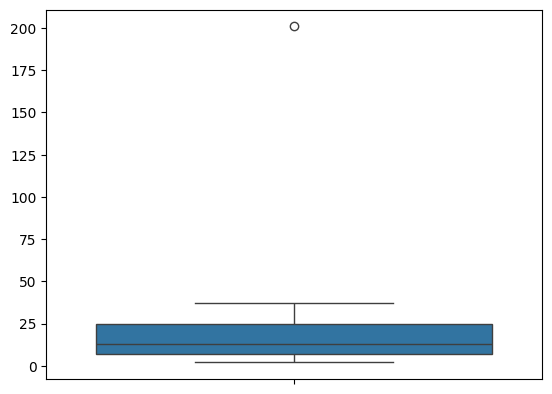

In [9]:
import seaborn as sns

sns.boxplot(arr)

<Axes: >

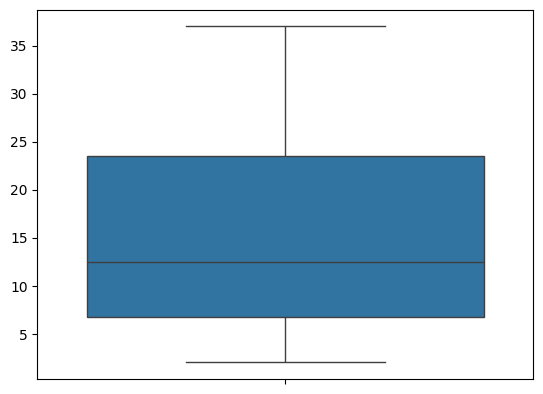

In [10]:
sns.boxplot(arr2)

# **Hythesis Testing**

## **Z- Test**   --> by p-value

In [11]:
import numpy as np
from scipy.stats import norm

In [12]:
# sample size must be greater than 30

In [13]:
sample = [172,174,168,169,171,173,175,170,169,172]

In [14]:
population_mean = 170
population_std = 3
sample_mean = np.mean(sample)
n = len(sample)

In [15]:
z_score = (sample_mean - population_mean)/(population_std/np.sqrt(n))
z_score

np.float64(1.3703203194063098)

In [16]:
p_value = 2 * (1 - norm.cdf(abs(z_score)))
p_value

np.float64(0.17058693287143756)

In [17]:
alpha = 0.05

if p_value < alpha:
  print('Reject the null hypothesis')
else:
  print(' Accept the null hypothesis')

 Accept the null hypothesis


# **T - test**

In [18]:
# more used as mostly sample s given

In [19]:
import numpy as np
from scipy import stats

In [20]:
sample = [172, 174 ,168, 169, 171 , 173, 175, 170, 169, 172]
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof = 1)
n = len(sample)
mean_population = 170

In [21]:
t_score = (sample_mean - mean_population)/(sample_std/np.sqrt(n))
t_score

np.float64(1.7782469350914734)

In [22]:
p_value = 2 * (1 - stats.t.cdf(abs(t_score), df = n-1))
p_value

np.float64(0.10907771593031335)

In [23]:
if p_value < alpha:
  print('Reject the null hypothesis')
else:
  print(' Accept the null hypothesis')

 Accept the null hypothesis


# **Two sample_ T - test**

In [24]:
import numpy as np
from scipy import stats

In [25]:
group_A=[85,88,90,92,87,85,89,91,86,88]
group_B=[82,84,80,83,81,79,78,85,84,83]

In [26]:
t_stats , p_value = stats.ttest_ind(group_A,group_B,equal_var=False)

In [27]:
t_stats

np.float64(5.829604009507161)

In [28]:
p_value

np.float64(1.610475598965881e-05)

In [29]:
aplha = 0.05
if p_value < alpha:
  print('Reject the null hypothesis')
else:
  print(' Accept the null hypothesis')


Reject the null hypothesis


# **chi square test**

In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

In [31]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [32]:
contingency_table = pd.crosstab(df['sex'],df['survived'])
contingency_table

survived,0,1
sex,,
female,81,233
male,468,109


In [33]:
chi2 , p_value , dof ,expected = chi2_contingency(contingency_table)

In [34]:
expected

array([[193.47474747, 120.52525253],
       [355.52525253, 221.47474747]])

In [36]:
p_value

np.float64(1.1973570627755645e-58)

In [37]:
alpha = 0.05

if p_value < aplha :
  print('We reject the null hypothesis and  there is a significant relationship between sex and survival')
else:
  print('We accept the null hypothesis and there is no significant relationship between sex and survival')

We reject the null hypothesis and  there is a significant relationship between sex and survival


# **ANNOVA Test**

In [38]:
import pandas as pd
from scipy.stats import f_oneway

In [39]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [44]:
df = df[['age','pclass']].dropna()

In [45]:
df['pclass'].unique()

array([3, 1, 2])

In [46]:
class1 = df[df['pclass'] == 1]['age']
class2 = df[df['pclass'] == 2]['age']
class3 = df[df['pclass'] == 3]['age']
class1

,age
1,38.0
3,35.0
6,54.0
11,58.0
23,28.0
...,...
871,47.0
872,33.0
879,56.0
887,19.0


In [47]:
f_stats , p_value = f_oneway(class1,class2,class3)

In [48]:
f_stats

np.float64(57.44348434067624)

In [49]:
p_value

np.float64(7.487984171959213e-24)

In [52]:
aplha = 0.05

if p_value < aplha:
  print('Reject the null hypothesis and there is a significant differnce in atleast one passenger class')
else:
  print('Accept the null hypothesis and there is no significant diff')

Reject the null hypothesis and there is a significant differnce in atleast one passenger class
